In [1]:
import json
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings("ignore")

In [55]:
# ── CONFIG ───────────────────────────────────────────────────
MODEL_PATH = Path(f"results/word2vec")
MODEL_PATH.mkdir(exist_ok=True)


# ── YOUR COLUMN NAMES ────────────────────────────────────────
TEXT_COL      = "text_preprocessed_lemmatized"  # already lemmatised 
FALLBACK_COL  = "text_preprocessed"             # if lemmatized is empty
DATE_COL      = "date_year"
PARTY_COL     = "Party"
SEP           = ";"                            # tab-separated

# ── WORD2VEC SETTINGS ────────────────────────────────────────
VECTOR_SIZE   = 100
WINDOW        = 7
MIN_COUNT     = 10
EPOCHS        = 50
WORKERS       = 4
TOP_N         = 20
MIN_SIM       = 0.72

### Keyword Seed Lexicons for Welcoming and Restrictive Stance Classification

In [10]:
WELCOMING_SEEDS = [
    # Skilled Labor & Workforce Need
    "fachkraefteeinwanderungsgesetz",
    "fachkraeftezuwanderungsgesetz",
    "fachkraefteeinwanderung",
    "fachkraeftesicherung",
    "fachkraeftemangel",
    "fachkraeftemangels",
    "fachkraeftebedarf",
    "qualifiziert",
    "arbeitskraefteeinwanderung",
    "hochqualifizierte",
    "fachkraeften",
    "arbeitsvisa",
    "ausbilden",
    "sprachfoerderung",
    "integration",
    "einbuergerung",
    "staatsbuergerschaft",
    "spracherwerb",
    "integrationsmassnahmen",
    
]

RESTRICTIVE_SEEDS = [
    "belastungsgrenzen",
    "belastbarkeit",
    "unterqualifizierter",
    "asyltourismus",
    "belasten",
    "ueberlastung",
    "ueberlasten",
    "lohndumping",
    "erschoepfen",
    "lasten",
    "ablehnen",
    "ueberlastung",
    "migrationsfolgekosten",
    # Welfare System & Exploitation
    "sozialleistungsmissbrauch",
    "wirtschaftsmigranten",
    "einwanderungsquote",
    "geringqualifiziert",
    "wohnungsmangel",
    "belastungsgrenze",
    "wirtschaftsfluechtlinge",
    "zusatzkosten",
    "asylstrom",
    "armutsfluechtlinge",
    "fluechtlingsstroms",
    "massenzustrom",
    "asylbewerberzustroms",
    # Infrastructure & Labor Competition
    "schwarzarbeit",
    "clanbildung",
    "irregulaere" ,
    "nichtqualifizierten", 

]

In [4]:
# PREPARE TOKENS

print("\n Preparing tokens from pre-lemmatised column")

def text_to_tokens(text) -> list[str]:
    """
    Just split on whitespace and clean.
    """
    if pd.isna(text) or str(text).strip() == "":
        return []
    tokens = str(text).lower().split()
    # keep only alphabetic tokens longer than 2 chars
    return [t for t in tokens if t.isalpha() and len(t) > 2]

# Use lemmatized column; fall back to preprocessed if empty
def get_tokens(row) -> list[str]:
    tokens = text_to_tokens(row.get(TEXT_COL, ""))
    if len(tokens) < 3:
        tokens = text_to_tokens(row.get(FALLBACK_COL, ""))
    return tokens




 Preparing tokens from pre-lemmatised column


In [6]:

df_imm       = pd.read_csv("./results/immigration_speeches_short.csv")
imm_tokens   = [get_tokens(row) for _, row in df_imm.iterrows()
                if len(get_tokens(row)) >= 5]

### Word2Vec Model Training and Vocabulary Inspection Pipeline

In [58]:
# STEP 4 — TRAIN WORD2VEC
print("\nSTEP 4 — Training Word2Vec on CPU")

if MODEL_PATH.exists():
    print(f"  Loading existing model from {MODEL_PATH}...")
    w2v = Word2Vec.load("./output_dictionaries/word2vec/word2vec_bundestag.model")
else:
    MODEL_PATH.mkdir(exist_ok=True)
    print("  Training from scratch...")
    w2v = Word2Vec(
        sentences   = imm_tokens,
        vector_size = VECTOR_SIZE,
        window      = WINDOW,
        min_count   = MIN_COUNT,
        epochs      = EPOCHS,
        workers     = WORKERS,
        sg          = 1,      # skip-gram
        seed        = 42
    )
    w2v.save(str(MODEL_PATH / f"word2vecModel"))
    print(f"  Saved to {MODEL_PATH}")

print(f"  Vocabulary: {len(w2v.wv):,} words")

# Quick sanity check
for probe in ["fluechtling", "abschiebung", "integration"]:
    if probe in w2v.wv:
        top3 = [w for w, _ in w2v.wv.most_similar(probe, topn=3)]
        print(f"  most_similar('{probe}'): {top3}")
    else:
        print(f"  '{probe}' NOT in vocabulary")



STEP 4 — Training Word2Vec on CPU
  Training from scratch...
  Saved to results/word2vec
  Vocabulary: 44,863 words
  most_similar('fluechtling'): ['fluecht', 'fluechtlin', 'gefluechtete']
  most_similar('abschiebung'): ['abschieben', 'bleiberecht', 'ausreisepflichtige']
  most_similar('integration'): ['gration', 'integrationspolitik', 'tegration']


In [93]:
w2v = Word2Vec.load("./results/word2vec/word2vecModel")

In [94]:

print("\nSTEP 5 — Mining dictionary candidates")
def mine_candidates(seeds: list[str],
                    model: Word2Vec,
                    topn: int = TOP_N) -> dict[str, float]:
    candidates = defaultdict(float)
    missing    = []
    for seed in seeds:
        if seed not in model.wv:
            missing.append(seed)
            continue
        for word, sim in model.wv.most_similar(seed, topn=topn):
            candidates[word] = max(candidates[word], sim)
    if missing:
        print(f"  Not in vocab: {missing}")
    print(f"  Raw candidates: {len(candidates)}")
    return dict(candidates)

print("Mining WELCOMING...")
w_cands = mine_candidates(WELCOMING_SEEDS, w2v)

print("Mining RESTRICTIVE...")
r_cands = mine_candidates(RESTRICTIVE_SEEDS, w2v)

# Remove overlap — assign to the side with higher similarity
overlap = set(w_cands) & set(r_cands)
print(f"\nAmbiguous (in both): {len(overlap)} — resolving by score...")
ambiguous_resolved = {}
for word in overlap:
    ws, rs = w_cands[word], r_cands[word]
    
    del r_cands[word]
    ambiguous_resolved[word] = ("welcoming", round(ws, 4), round(rs, 4))
    
    del w_cands[word]
    ambiguous_resolved[word] = ("restrictive", round(ws, 4), round(rs, 4))


STEP 5 — Mining dictionary candidates
Mining WELCOMING...
  Not in vocab: ['integrationswillig', 'weg', 'nachkriegsdemokratie', 'modernen', 'friedliches', 'kursangebot', 'nieuren', 'ntegrationscenter', 'enthaltsstatus', 'arbeitsvisa', 'deutschsprachfoerderungen', 'integrationspakt', 'kulturnah', 'attraktiver', 'integrationsinitiativen', 'alphabetisierungskursen', 'fachkraeftekrise', 'verantwortung', 'solidarleistungen', 'luechtling', 'wahren', 'ar', 'zeigen', 'gelingen', 'integrationshilfe', 'solidaritaetsgedanken', 'pflicht', 'puterexperten', 'hilfe', 'aussiedle', 'engpassberufen', 'behandeln', 'integrationsunwillig', 'sittengesetz', 'recht', 'ermoelichen', 'asy', 'greencardregelung', 'weihnachtsmarktmoerders', 'deutschfoerderung', 'angehen', 'einbuergerungsansprueche', 'behandlung', 'fluechtlingskonventiondauerhaft', 'wanderungsgesellschaft', 'beratungskapazitae', 'nachbarschaftstreffen', 'arbeitskraeftereserven', 'bildungszugang', 'angfristig', 'arbeitsmigrationsrecht', 'integratio

In [95]:
# STEP 6 — TF-IDF FILTER
print("\nSTEP 6 — TF-IDF filter (immigration-specific terms only)")

# Fit TF-IDF on immigration speeches
imm_docs = [" ".join(t) for t in imm_tokens if t]
#all_docs  = [" ".join(t) for t in all_tokens[:15_000] if t]  # sample

tfidf = TfidfVectorizer(max_features=80_000, min_df=2)
tfidf.fit(imm_docs)
tfidf_vocab = set(tfidf.get_feature_names_out())

def apply_filters(candidates: dict[str, float]) -> dict[str, float]:
    return {
        w: s for w, s in candidates.items()
        if s >= MIN_SIM
        and w in tfidf_vocab
        and len(w) > 3
        and w.isalpha()
    }

w_final = apply_filters(w_cands)
r_final = apply_filters(r_cands)

print(f"  Welcoming:   {len(w_cands)} → {len(w_final)}")
print(f"  Restrictive: {len(r_cands)} → {len(r_final)}")


STEP 6 — TF-IDF filter (immigration-specific terms only)
  Welcoming:   2866 → 118
  Restrictive: 3980 → 126


In [96]:
OUTPUT_DIR = Path("./output_dictionaries")
# STEP 7 — EXPORT
print("\nSTEP 7 — Saving dictionaries")

def make_df(cands: dict, col: str) -> pd.DataFrame:
    return pd.DataFrame(
        sorted(cands.items(), key=lambda x: x[1], reverse=True),
        columns=[col, "similarity_score"]
    )

df_w = make_df(w_final, "welcoming_terms")
df_r = make_df(r_final, "restrictive_terms")

#  Same format as your fiscal dictionaries (single column)
df_w[["welcoming_terms"]].to_csv(
    OUTPUT_DIR / "welcoming_terms_preprocessed.csv", index=False)
df_r[["restrictive_terms"]].to_csv(
    OUTPUT_DIR / "restrictive_terms_preprocessed.csv", index=False)

# Scored version (for your validation review)
df_w.to_csv(OUTPUT_DIR / "welcoming_terms_scored.csv",   index=False)
df_r.to_csv(OUTPUT_DIR / "restrictive_terms_scored.csv", index=False)

# Ambiguous terms (for manual assignment)
pd.DataFrame([
    {"term": w, "assigned_to": v[0],
     "sim_welcoming": v[1], "sim_restrictive": v[2]}
    for w, v in ambiguous_resolved.items()
]).to_csv(OUTPUT_DIR / "ambiguous_terms.csv", index=False)


STEP 7 — Saving dictionaries


### Filtering of commun words in the two dictionaries

In [97]:
df_res = pd.read_csv("./../dictionaries/restrictive_terms_preprocessed03.csv", low_memory=False)

In [98]:
len(df_res.restrictive_terms.unique())

872

In [99]:
df_wel = pd.read_csv("./../dictionaries/welcoming_terms_preprocessed03.csv", low_memory=False)
len(df_wel.welcoming_terms.unique())

655

In [100]:
df_res = pd.read_csv("./../dictionaries/restrictive_terms_preprocessed03.csv", sep=SEP, low_memory=False)
RESTRICTIVE_SEEDS = df_res["restrictive_terms"].to_list()
RESTRICTIVE_SEEDS = set(df_r["restrictive_terms"].to_list() + RESTRICTIVE_SEEDS)
len(RESTRICTIVE_SEEDS)

968

In [101]:
RESTRICTIVE_SEEDS = [word for item in RESTRICTIVE_SEEDS for word in item.split()]
len(RESTRICTIVE_SEEDS)

968

In [102]:
df_wel = pd.read_csv("./../dictionaries/welcoming_terms_preprocessed03.csv", sep=SEP, low_memory=False)
WELCOMING_SEEDS = df_wel["welcoming_terms"].to_list()
WELCOMING_SEEDS = set(df_w["welcoming_terms"].to_list() + WELCOMING_SEEDS)
WELCOMING_SEEDS = [word for item in WELCOMING_SEEDS for word in item.split()]
len(WELCOMING_SEEDS)

755

In [82]:
RESTRICTIVE_SEEDS_FILTER = RESTRICTIVE_SEEDS
WELCOMING_SEEDS_FILTER = WELCOMING_SEEDS

### PCA Dimensionality Reduction and Scatter Plot Visualization for Word2Vec Embeddings

Welcoming words: 590
Restrictive words: 718


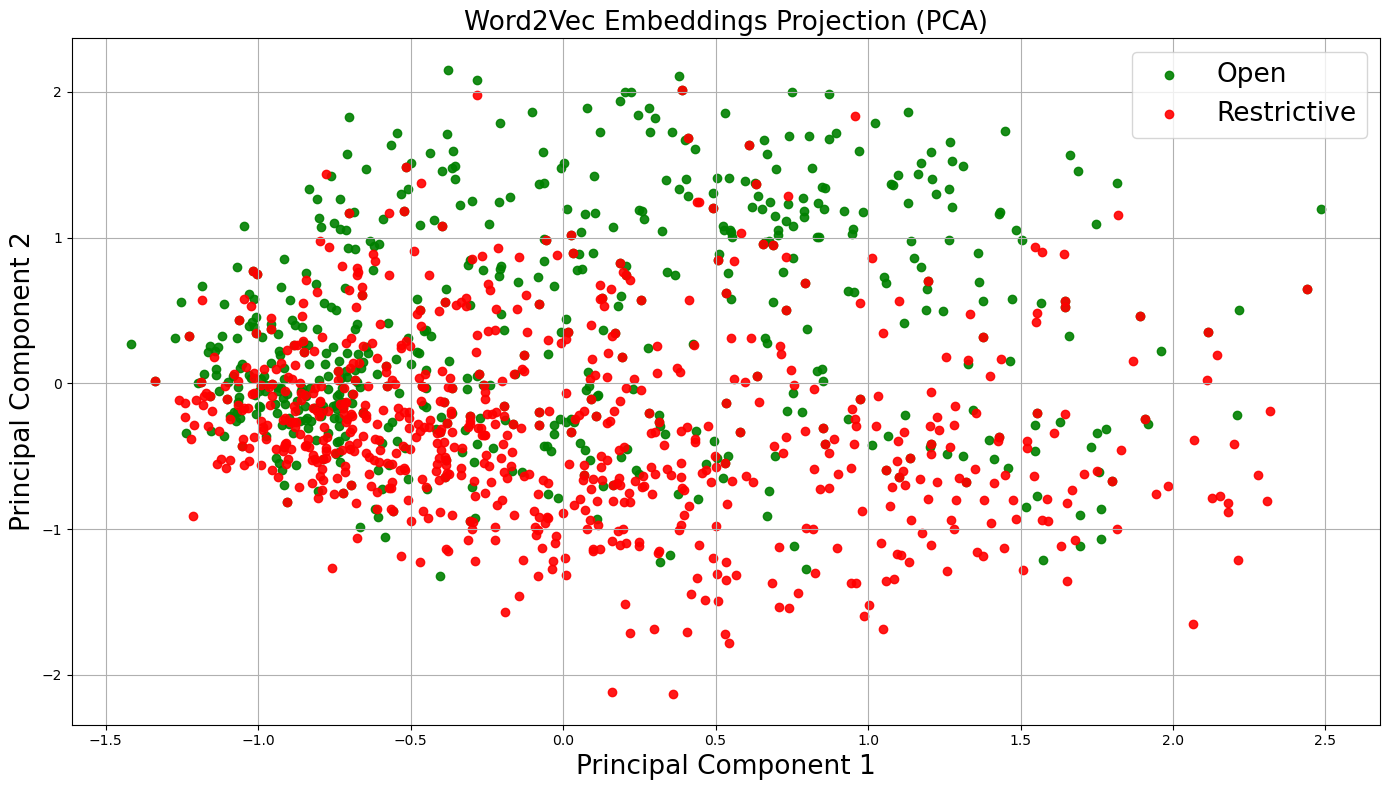

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ---------------------------------------------------
# 1. Keep words in vocabulary
# ---------------------------------------------------
welcoming_words = [w for w in WELCOMING_SEEDS_FILTER if w in w2v.wv]
restrictive_words = [w for w in RESTRICTIVE_SEEDS_FILTER if w in w2v.wv]

# ---------------------------------------------------
# 2. Extract vectors
# ---------------------------------------------------
welcoming_vectors = np.array([w2v.wv[w] for w in welcoming_words])
restrictive_vectors = np.array([w2v.wv[w] for w in restrictive_words])

# ---------------------------------------------------
# 3. Build metadata
# ---------------------------------------------------
all_vectors = np.vstack([welcoming_vectors, restrictive_vectors])

all_words = welcoming_words + restrictive_words

all_labels = (
    ["welcoming"] * len(welcoming_words) +
    ["restrictive"] * len(restrictive_words)
)

# ---------------------------------------------------
# 4. Shuffle everything together
# ---------------------------------------------------
np.random.seed(42)

idx = np.random.permutation(len(all_vectors))

all_vectors = all_vectors[idx]
all_words   = np.array(all_words)[idx]
all_labels  = np.array(all_labels)[idx]

# ---------------------------------------------------
# 5. PCA after shuffling
# ---------------------------------------------------
pca = PCA(n_components=2, random_state=12)
vectors_2d = pca.fit_transform(all_vectors)

# ---------------------------------------------------
# 6. Recover groups using labels
# ---------------------------------------------------
welcome_mask = all_labels == "welcoming"
restrict_mask = all_labels == "restrictive"

welcome_2d = vectors_2d[welcome_mask]
restrict_2d = vectors_2d[restrict_mask]

# ---------------------------------------------------
# 7. Plot
# ---------------------------------------------------
plt.figure(figsize=(14,8))

# Plot welcoming
plt.scatter(
    vectors_2d[welcome_mask, 0],
    vectors_2d[welcome_mask, 1],
    label="Open",
    alpha=0.9,
    color="green"
)

# Plot restrictive
plt.scatter(
    vectors_2d[restrict_mask, 0],
    vectors_2d[restrict_mask, 1],
    label="Restrictive",
    alpha=0.9,
    color="red"
)

# ---------------------------------------------------
# 8. Optional labels
# ---------------------------------------------------
# for i in range(20):

#     x = vectors_2d[i, 0]
#     y = vectors_2d[i, 1]

#     plt.annotate(
#         all_words[i],
#         (x, y),
#         fontsize=7
#     )

# ---------------------------------------------------
# 9. Final formatting
# ---------------------------------------------------
print("Welcoming words:", np.sum(welcome_mask))
print("Restrictive words:", np.sum(restrict_mask))

plt.title("Word2Vec Embeddings Projection (PCA)",fontsize = 19)
plt.xlabel("Principal Component 1",fontsize = 19)
plt.ylabel("Principal Component 2",fontsize = 19)
plt.legend(fontsize = 19)
plt.grid(True)
plt.tight_layout()
plt.show()

### Filtered PCA Dimensionality Reduction and Coordinate Threshold Scatter Plot for Word2Vec Embeddings

open words: 241
Restrictive words: 288


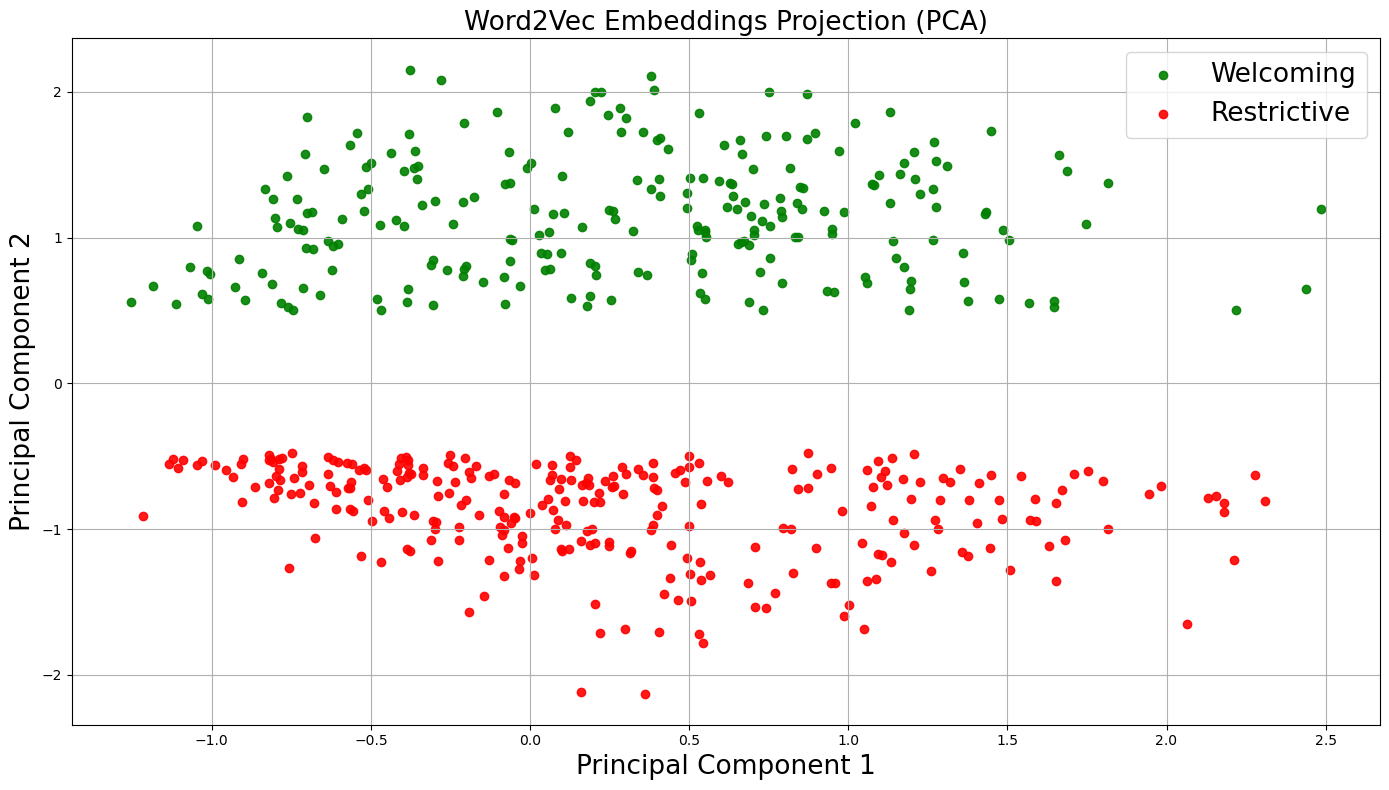

In [105]:
# ---------------------------------------------------
# 1. Keep words in vocabulary
# ---------------------------------------------------
welcoming_words = [w for w in WELCOMING_SEEDS_FILTER if w in w2v.wv]
restrictive_words = [w for w in RESTRICTIVE_SEEDS_FILTER if w in w2v.wv]

# ---------------------------------------------------
# 2. Extract vectors
# ---------------------------------------------------
welcoming_vectors = np.array([w2v.wv[w] for w in welcoming_words])
restrictive_vectors = np.array([w2v.wv[w] for w in restrictive_words])

# ---------------------------------------------------
# 3. Build metadata
# ---------------------------------------------------
all_vectors = np.vstack([welcoming_vectors, restrictive_vectors])

all_words = welcoming_words + restrictive_words

all_labels = (
    ["welcoming"] * len(welcoming_words) +
    ["restrictive"] * len(restrictive_words)
)

# ---------------------------------------------------
# 4. Shuffle everything together
# ---------------------------------------------------
np.random.seed(42)

idx = np.random.permutation(len(all_vectors))

all_vectors = all_vectors[idx]
all_words   = np.array(all_words)[idx]
all_labels  = np.array(all_labels)[idx]

# ---------------------------------------------------
# 5. PCA after shuffling
# ---------------------------------------------------
pca = PCA(n_components=2, random_state=12)
vectors_2d = pca.fit_transform(all_vectors)

# ---------------------------------------------------
# 6. Recover groups using labels
# ---------------------------------------------------
welcome_mask = all_labels == "welcoming"
restrict_mask = all_labels == "restrictive"

welcome_2d = vectors_2d[welcome_mask]
restrict_2d = vectors_2d[restrict_mask]

welcome_2d = welcome_2d[welcome_2d[:, 1] >=0.5]
restrict_2d = restrict_2d[restrict_2d[:, 1] < -0.48]

# ---------------------------------------------------
# 7. Plot
# ---------------------------------------------------
plt.figure(figsize=(14,8))

# Plot welcoming
plt.scatter(
    welcome_2d[:, 0],
    welcome_2d[:, 1],
    label="Welcoming",
    alpha=0.9,
    color="green"
)

# Plot restrictive
plt.scatter(
    restrict_2d[:, 0],
    restrict_2d[:, 1],
    label="Restrictive",
    alpha=0.9,
    color="red"
)

# ---------------------------------------------------
# 8. Optional labels
# ---------------------------------------------------
# for i in range(len(all_words)):

#     x = vectors_2d[i, 0]
#     y = vectors_2d[i, 1]

#     plt.annotate(
#         all_words[i],
#         (x, y),
#         fontsize=7
#     )

# ---------------------------------------------------
# 9. Final formatting
# ---------------------------------------------------
print("open words:", len(welcome_2d))
print("Restrictive words:", len(restrict_2d))

plt.title("Word2Vec Embeddings Projection (PCA)",fontsize = 19)
plt.xlabel("Principal Component 1",fontsize = 19)
plt.ylabel("Principal Component 2",fontsize = 19)
plt.legend(fontsize = 19)
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:

welcome_idx = np.where(welcome_2d[:, 1] > 0.5)[0]
selected_welcoming_words = [welcoming_words[i] for i in welcome_idx]
print(selected_welcoming_words)

['solidaritaetsgedanken', 'qualifikation', 'mehrstaatlichkeit', 'orientierungskurse', 'verantwortlich', 'erhoehen', 'qualifizieren', 'asylberechtigt', 'verteilung', 'hinweg', 'integrationspolitik', 'erwerbsfaehig', 'menschliche', 'einbuergerungsanspruch', 'ausbildungschancen', 'buergerkriegsfluechtlingen', 'menschenwuerde', 'beschaeftigung', 'grundrechts', 'facharbeitskraefte', 'migrationsabkommen', 'bleibeperspektiven', 'rechtssicherheit', 'staatsbuergerschaft', 'arbeitskraefte', 'bauen', 'zusammenhalts', 'voranzukommen', 'nachhaltig', 'integrati', 'arbeitsmarktintegration', 'integrationsmoeglichkeiten', 'auslaender', 'ausweiten', 'integra', 'fluechtlingspakt', 'versorgung', 'verteilen', 'zugewanderte', 'sittengesetz', 'fachkraefteproblem', 'arbeitsmigrantinnen', 'temangel', 'zuwanderungs', 'syrien', 'zukunftsfest', 'auslaenderfeindlichkeit', 'einwanderungslandes', 'vermitteln', 'einwanderungslaendern', 'menschenwuerdig', 'familienzusammenfuehrung', 'integrieren', 'willkommenskultur',

In [35]:
restrict_idx = np.where(restrict_2d[:, 1] < -0.48)[0]
selected_restrictive_words = [restrictive_words[i] for i in restrict_idx]

print(selected_restrictive_words)

['raus', 'zahlreiche', 'ueberwiegen', 'grenzuebertritt', 'unkontrollierten', 'errichten', 'afrikanisch', 'sicherheitsgewinn', 'naturgemaess', 'erhoehen', 'weihnachtsmaerkte', 'qualifizieren', 'strapazierung', 'einwanderungsquote', 'schaden', 'gewaltverbrecher', 'enorme', 'sicherheitspruefung', 'steigend', 'auslaenderfeindlich', 'asylant', 'beschaeftigung', 'aufzeigen', 'migrationsabkommen', 'einreisende', 'zaun', 'staatsbuergerschaft', 'ungesteuerten', 'gesundheitsfonds', 'erpresser', 'visapflicht', 'arbeitskraefte', 'druck', 'lohndum', 'abwanderung', 'nachhaltig', 'absolut', 'belasten', 'duldungen', 'zeitarbeitsbranche', 'auslaender', 'parallele', 'ungeloesten', 'ausweiten', 'nachzug', 'unkontrollierte', 'asylmissbrauchs', 'gettoisierung', 'versorgung', 'radikale', 'salafisten', 'kriminalstatistik', 'nation', 'abschiebungshindernisse', 'auslaenderfeindlichkeit', 'einreise', 'bundespolizei', 'ueberforderung', 'chaos', 'isolieren', 'wohnungssuchende', 'migrationswende', 'motivieren', 'g

###  Exporting Filtered Welcoming and Restrictive Word Lists to CSV Files

In [36]:
# Save welcoming words
with open("./results/new_welcoming_words.csv", "w", encoding="utf-8") as f:
    for word in selected_welcoming_words:
        f.write(word + "\n")

# Save restrictive words
with open("./results/new_restrictive_words.csv", "w", encoding="utf-8") as f:
    for word in selected_restrictive_words:
        f.write(word + "\n")